In [13]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [14]:
df = pd.read_sql(
    'SELECT * FROM "SectorCO2s";',
    engine
)
df

,Id,Year,Energy,Heat,Transport,Industrial_processes,Waste,Agriculture,Total
0,19,2008,8196.0,1328.0,1390.0,906.0,844.0,1376.0,14040.0
1,20,2009,8268.0,1375.0,1432.0,937.0,847.0,1517.0,14376.0
2,21,2010,9584.0,1423.0,1475.0,970.0,850.0,1553.0,15855.0
3,22,2011,9836.0,1472.0,1520.0,1004.0,853.0,1595.0,16280.0
4,23,2012,10025.0,1524.0,1566.0,1039.0,856.0,1637.0,16647.0
5,24,2013,10154.0,1577.0,1614.0,1076.0,859.0,1679.0,16959.0
6,25,2014,10246.0,1632.0,1664.0,1113.0,862.0,1722.0,17239.0
7,26,2015,11388.0,1690.0,1715.0,1152.0,865.0,1764.0,18574.0
8,27,2016,11719.0,1740.0,1775.0,1187.0,868.0,1807.0,19096.0
9,28,2017,12006.0,1792.0,1838.0,1222.0,871.0,1851.0,19580.0


In [15]:
df = df.drop(columns=["Id"])
columns_to_model = df.columns.drop("Year")
future_years = pd.DataFrame({"Year": [2026, 2027, 2028, 2029]})

In [16]:
import os

os.makedirs("../models/SectorCO2s", exist_ok=True)

In [17]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.linear_model import Ridge
import joblib
import pandas as pd

forecasts = {}
best_params = {}
loo = LeaveOneOut()

for col in columns_to_model:
    X = df[["Year"]].values
    y = df[col].values

    ridge = Ridge()
    param_grid = {
        "alpha": [0.01, 0.1, 1, 10],
        "fit_intercept": [True, False]
    }

    grid = GridSearchCV(ridge, param_grid, cv=loo, scoring='neg_mean_squared_error')
    grid.fit(X, y)

    best_model = grid.best_estimator_
    best_params[col] = grid.best_params_

    pred = best_model.predict(future_years[["Year"]].values)
    forecasts[col] = pred

    joblib.dump(best_model, f"../models/SectorCO2s/{col}_ridge_model.pkl")

df_forecast = pd.DataFrame(forecasts, index=future_years["Year"])
print(df_forecast)

print("\nBest parameters per column:")
for col, params in best_params.items():
    print(f"{col}: {params}")

            Energy         Heat    Transport  Industrial_processes  \
Year                                                                 
2026  15331.954457  2300.165655  2422.881794           1568.345569   
2027  15717.610482  2355.323444  2483.576954           1605.943348   
2028  16103.266506  2410.481232  2544.272114           1643.541127   
2029  16488.922531  2465.639020  2604.967273           1681.138907   

           Waste  Agriculture         Total  
Year                                         
2026  899.830467  2251.827832  24782.638373  
2027  902.958821  2296.552399  25370.401477  
2028  906.087174  2341.276966  25958.164580  
2029  909.215527  2386.001533  26545.927684  

Best parameters per column:
Energy: {'alpha': 1, 'fit_intercept': True}
Heat: {'alpha': 0.01, 'fit_intercept': True}
Transport: {'alpha': 1, 'fit_intercept': True}
Industrial_processes: {'alpha': 0.01, 'fit_intercept': True}
Waste: {'alpha': 0.1, 'fit_intercept': True}
Agriculture: {'alpha': 0.01, 'fi

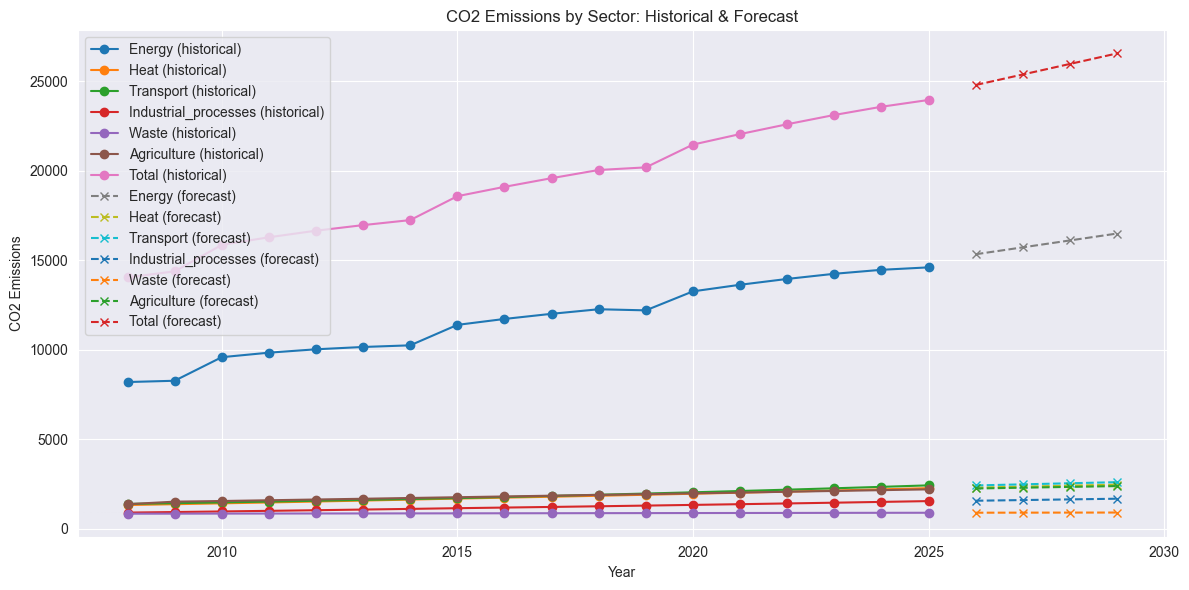

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for col in columns_to_model:
    plt.plot(df["Year"], df[col], marker='o', label=f"{col} (historical)")

for col in columns_to_model:
    plt.plot(future_years["Year"], df_forecast[col], marker='x', linestyle='--', label=f"{col} (forecast)")

plt.title("CO2 Emissions by Sector: Historical & Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
